
# DL Final Exam

**Name:** Maria Akter Mukti

**Course Email:**  mariamukti051@gmail.com


## End of Assignment

Before submitting:
- Run all cells from top to bottom.  
- Check that all answer sections are filled.  
- Instruction video অনুযায়ী আমাদের দেয়া Colab ফাইলটি থেকে প্রথম একটি Save copy in drive করে নিবা। এরপর Google colab এর মধ্যে কোডগুলো করবে এবং সেই ফাইলটি ‘Anyone with the link’ & ‘View’ Access দিয়ে ফাইলটির Shareble Link টি সাবমিট করবে।

# Question 01: [ Marks 10 ]

## Explain the concept of backpropagation in detail. Describe how the error is propagated from the output layer to the hidden layers. Derive the mathematical expressions for weight updates using the chain rule, and explain how learning rate affects the training process.


# Write Answer 01:
Backpropagation is an easy way to train a neural network.At first, the network takes input and gives an output.Then it checks if the prediction is correct or wrong. If it is wrong, the error is sent backward through the network. This helps the network understand which parts made the mistake.After that, it continuously changes the weights so it can do better next time.
It works in two steps:
1. Forward pass:
Input goes through the network then gives a prediction
2. Backward pass:
The error goes backward then weights are updated then again prediction improves next time.

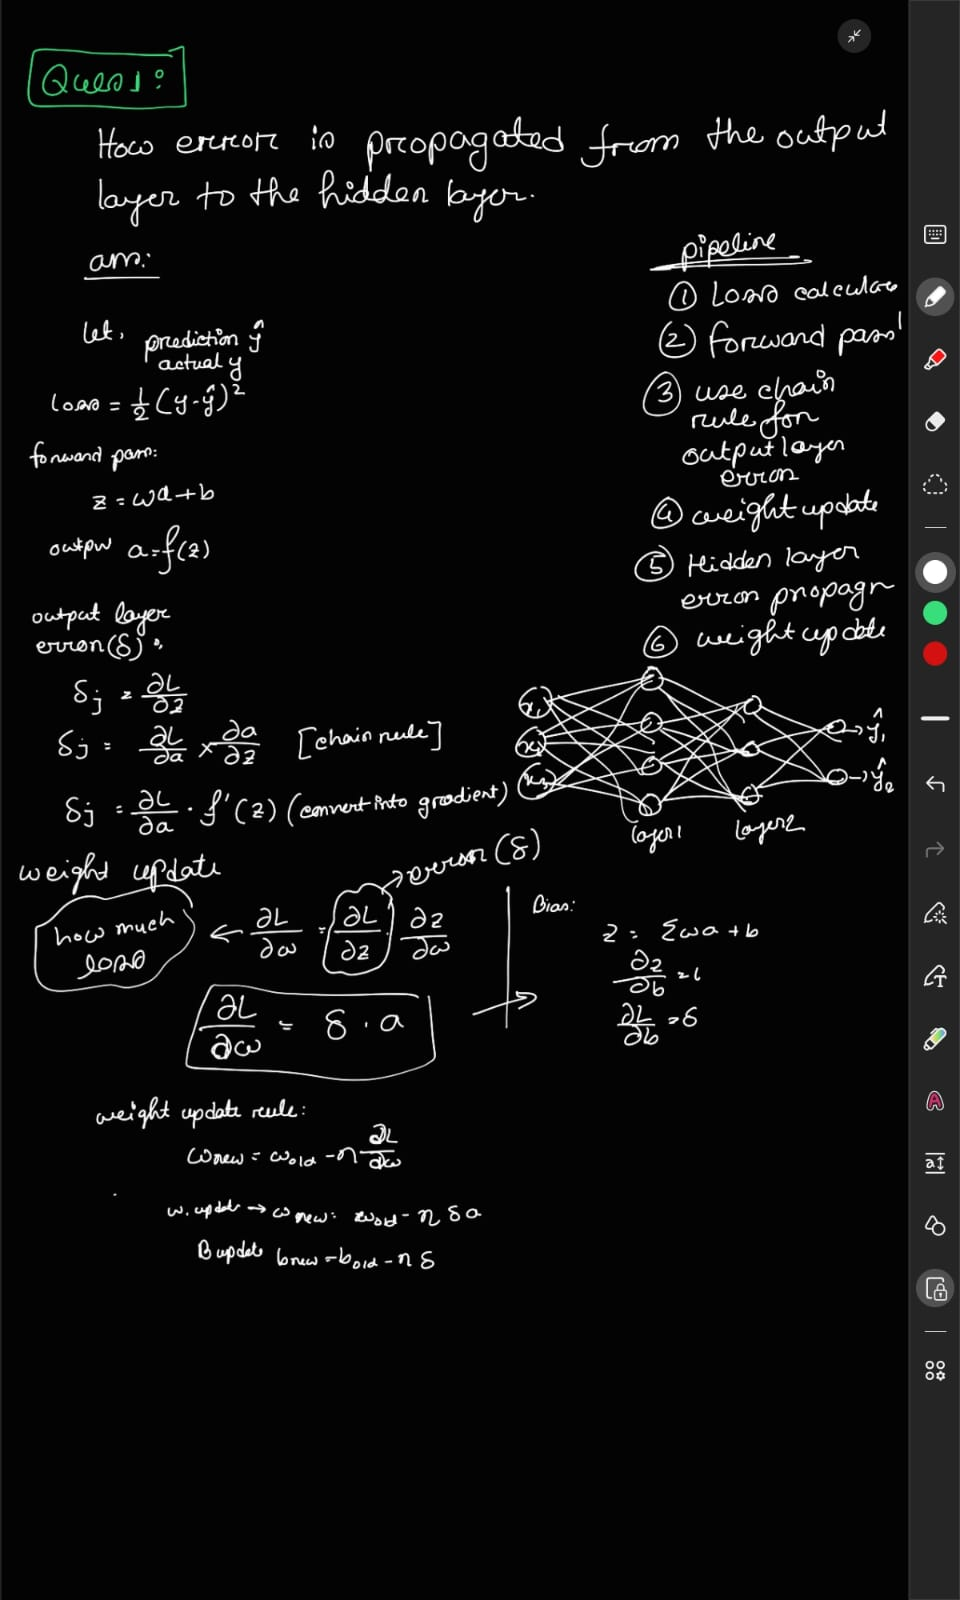

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [15]:
X = torch.randn(100, 3)
y = (X.sum(dim=1) > 0).float().unsqueeze(1)

In [16]:
model = nn.Sequential(
    nn.Linear(3, 5),
    nn.ReLU(),
    nn.Linear(5, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()

In [17]:
def train(lr):
    model_copy = nn.Sequential(
        nn.Linear(3, 5),
        nn.ReLU(),
        nn.Linear(5, 1),
        nn.Sigmoid()
    )

    optimizer = optim.SGD(model_copy.parameters(), lr=lr)

    losses = []

    for epoch in range(50):
        outputs = model_copy(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

In [18]:
loss1 = train(0.01)
loss2 = train(0.1)
loss3 = train(1.0)

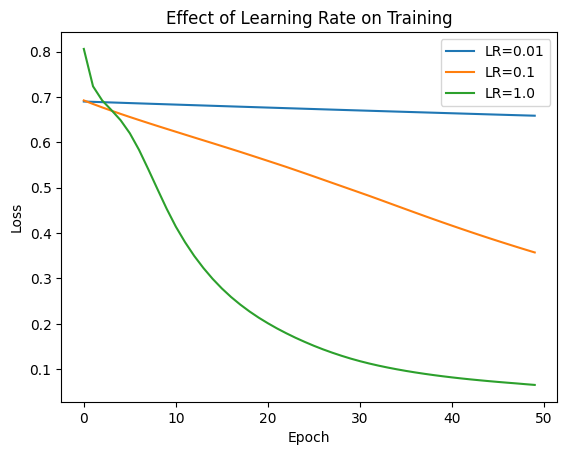

In [19]:
plt.plot(loss1, label="LR=0.01")
plt.plot(loss2, label="LR=0.1")
plt.plot(loss3, label="LR=1.0")

plt.legend()
plt.title("Effect of Learning Rate on Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

LR = 0.01-> slow decrease-> smooth curve

LR = 0.1-> fast and stable

LR = 1.0-> unstable type curve


# Question 02: [ Marks 10 ]

## Consider a neural network with one hidden layer using sigmoid activation. Derive the complete backpropagation equations for updating weights and biases. Show all steps clearly, including forward pass, loss calculation, and backward pass.

## Write Answer 02:


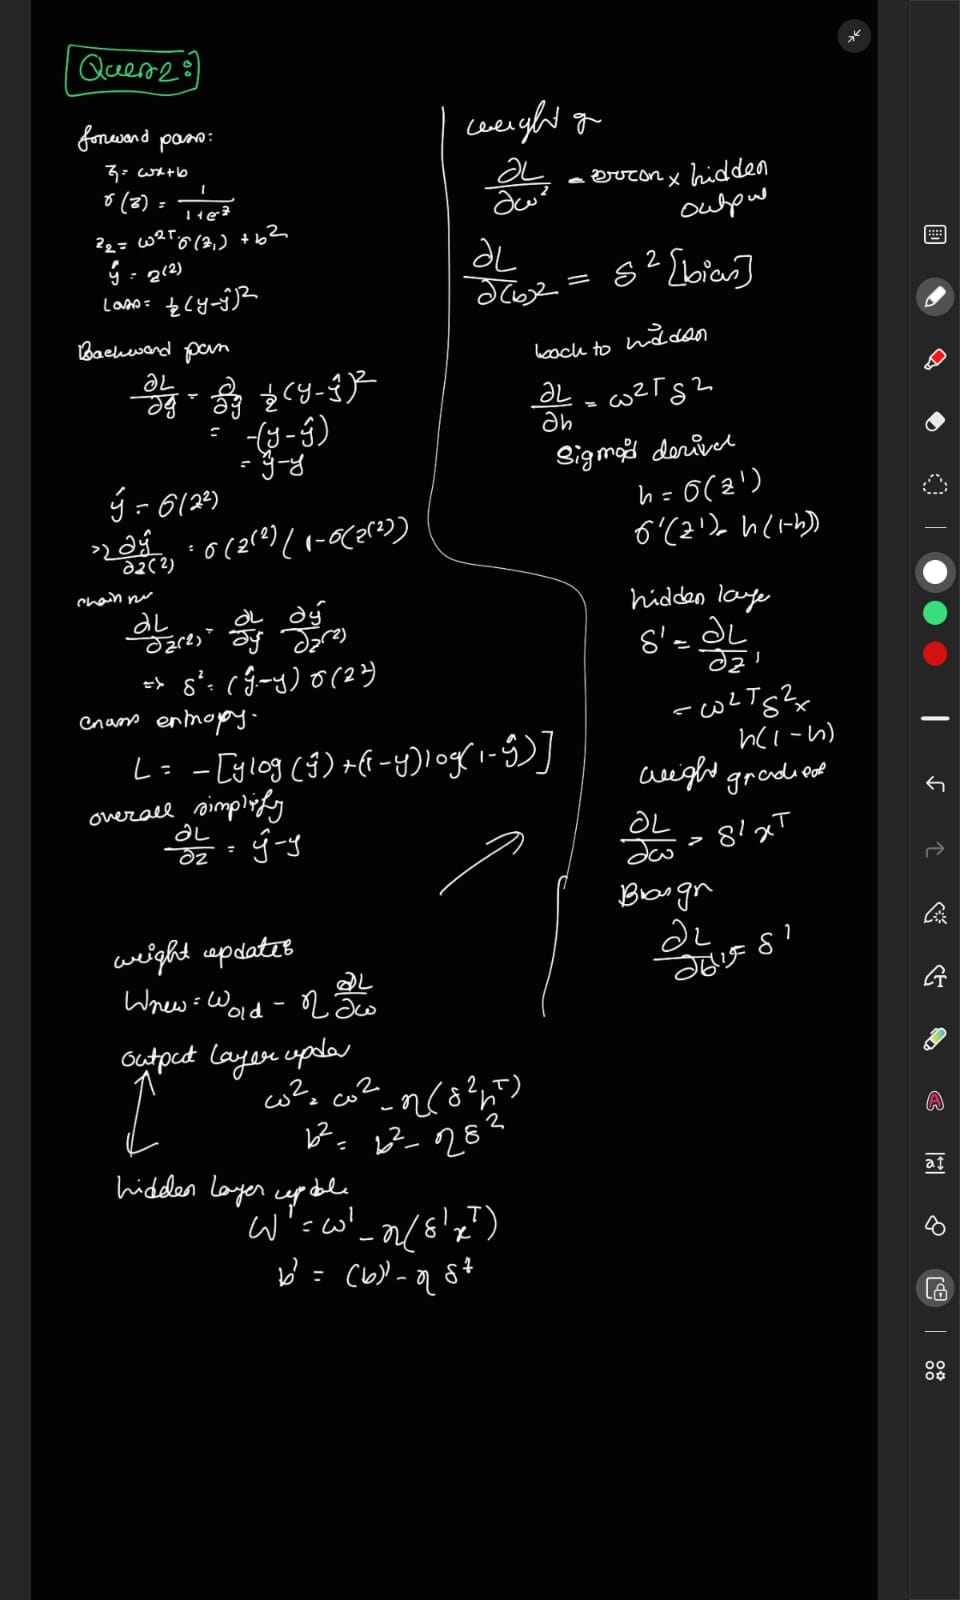

# Question 03: [Marks 5]

## Discuss the vanishing gradient problems in deep neural networks. Explain why they occur during backpropagation, how activation functions contribute to this issue, and suggest at least three techniques to overcome these problems.


## Write Answer 03:
In a deep neural network, sometimes the gradient becomes very small during training.
It happen when->

=> The earlier layers do not learn properly

=> The model becomes slow or fails to learn well

------------

During backpropagation, we use the chain rule.We multiply many small values together.As a result becomes very close to 0So, the gradient disapair.

------

Some activation functions make this worse:

1.Sigmoid function: Output is between 0 to 1. Its derivative is always very small. So when we multiply many small values, gradient becomes zero.

2.Tanh function: Better than sigmoid but still gives small gradients

--------

how to solve:

1. Using ReLU: f(x)=max(0,x).

it does not make graduient very small, it helps network learn more better.

2. Batch Normalization: Normalizes data inside each layer. it will makes training stable and faster.

3. Proper weight initialization: Maske sure that we will set initial weights properly.it will also keeps gradients stable.

# Question 04: [ Marks 5 ]

## Describe the architecture of an Artificial Neural Network (ANN) in detail. Explain the role of each component (neurons, weights, bias, activation functions). Also discuss how increasing the number of hidden layers and neurons affects model performance and overfitting.


## Write Answer 04:

An Artificial Neural Network (ANN) is a machine learning model inspired by the human brain. It is made of connected units called neurons, arranged in layers to process data and make predictions.

Main components:
1. Neurons: Neurons are the basic processing units of ANN.
Each neuron takes input, processes it, and produces an output.
It works like a small decision maker type things.

2. Weights: eights decide the importance of each input.
Each input is multiplied by a weight value.

=> Higher weight = more important input

=> Lower weight = less important input

Weights are learned during training.
3. Bias: Bias is an extra value added inside the neuron.
It helps the model shift the output up or downs.It helps the model make better decisions even when input is 0.

4. Activation Function: it decides whether a neuron should be activated or not.There are multiple activation functions such as: ReLU, Sigmoid, Tanh.
Without activation function, ANN can only solve simple linear problems not complex.

---------

Increase hidden layer:

adv:
Can learn complex patterns, Learns step by step features , Good for hard problems like image or speech.

disadv:
Training becomes slow, hard to train properly, overfitting risk increases.

------

Increasing Neurons:

adv:
Learns more information,can capture more patterns.

disadv:
May memorize training data, needs more computing power, may not work well on new data.

----

Overfitting ->when model learns training data too well but fails on new data.

It happens when:too many layers, and many neuroons,n ot enough training data

# Question 05: [ Marks 10 ]

## Compare Artificial Neural Networks (ANN) and Convolutional Neural Networks (CNN) in detail. Discuss their architectures, working principles, advantages, limitations, and typical use cases such as image processing, tabular data, and pattern recognition.

## Write Answer 05:

ANN: Every neuron is connected to every neuron in the next layer.
It has input, hidden, output layers.

Working Principle:Takes all inputs as a single vector.
Each input is processed equally.
No special understanding of spatial data. Example: Treats image pixels like simple numbers.

Advantages:
Simple to design. Works well for tabular data. Good for basic classification problems.

Limitations:
Not good for images or spatial data, too many parameters for large inputs, Can easily overfit

Use Cases:
Tabular data like student marks, Simple classification problems,Regression problems, Basic pattern recognition

-------------

CNN:it works like a filter system for images. it is designed to process image data efficiently

Working Principle: Uses filters to scan input, detects features step by step:
edges -> shapes -> objects
Example: Recognizes face, eyes, nose in an image

Advantages:
Best for image data,Automatically extracts features,High accuracy in vision tasks,Needs less manual feature engineering.

Limitations:
Complex architecture, Needs more computation power, Requires large dataset for good performance.

Use Cases:
faces recognition,Medical image analysis,Self-driving cars

# Question 06: [ Marks 10 ]

## Explain different activation functions used in neural networks, including Sigmoid, Tanh, and ReLU. Provide their mathematical formulas, advantages, disadvantages, and suitable use cases. Also discuss why ReLU is widely used in deep learning.

## Write Answer 06:

Activation function takes the input of a neuron and converts it into an output value. 3 types of activated function here: Sigmoid,Tanh,ReLU.

----------

Sigmoid function:

Advantages:

-> Easy to understand

-> Output between 0 and 1, so it is useful for probability related tasks.

-> Good for binary classification in output layer.

Disadvantages:

-> If input is very small or large, gradient becomes very small.

-> Not zero-centered, which can make training slower.

Suitable Use Cases:

->Binary classification output layer Example: spam vs not spam, disease vs no disease

-----

Tanh Activation Function:

Advantages:

-> Works better than sigmoid for many neural network hidden layers.

-> Stronger gradients than sigmoid around the center.

Disadvantages:

-> It face vanishing gradient problem for very large positive or negative values.

-> Also uses exponential function, so it is slower than ReLU.

Suitable Use Cases:

-> use in hidden layers when data is in -1 to +1.

example: profit or loss (+/-)

-----

ReLU:

Advantages:

-> Very fast and simple to compute.

-> also helps reduce the vanishing gradient problem.

-> Works very well in deep networks.


Disadvantages:

-> if a neuron always gets negative input, it may stop learning forever.

-> Output is not bounded on the positive side, which can sometimes create very large activations.

Suitable Use Cases:

almost all deep network we use it

-> Image processing

example: face recognation, object detechtion

---------

ReLU is Widely Used in Deep Learning: cause

1. Better performance: in most real problems, ReLU trains faster and gives better results.

2. Good for deep networks: ReLU helps signals pass through many layers easily.

3. Very fast to compute : ReLU = max(0, x) .It is simple, so training is quicker.

4. Negative input bcome 0 so less neurons activate so it is more efficient

5. ReLU keeps gradients for positive values, so learning is faster.

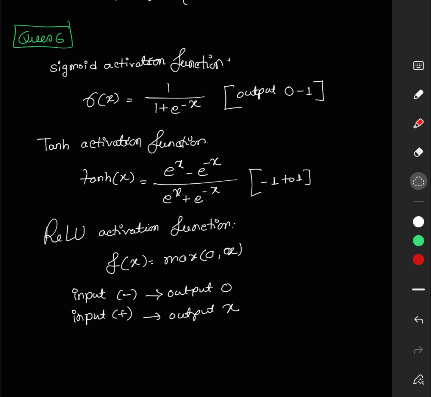

# Question 07: [ Marks 10 ]

## Describe the convolution operation in CNNs in detail. Explain how filters (kernels) work, how feature maps are generated, and how parameters like stride and padding affect the output. Provide a step-by-step example using a small input matrix.
Note :  You've to attach an image here.



## Write Answer 07:
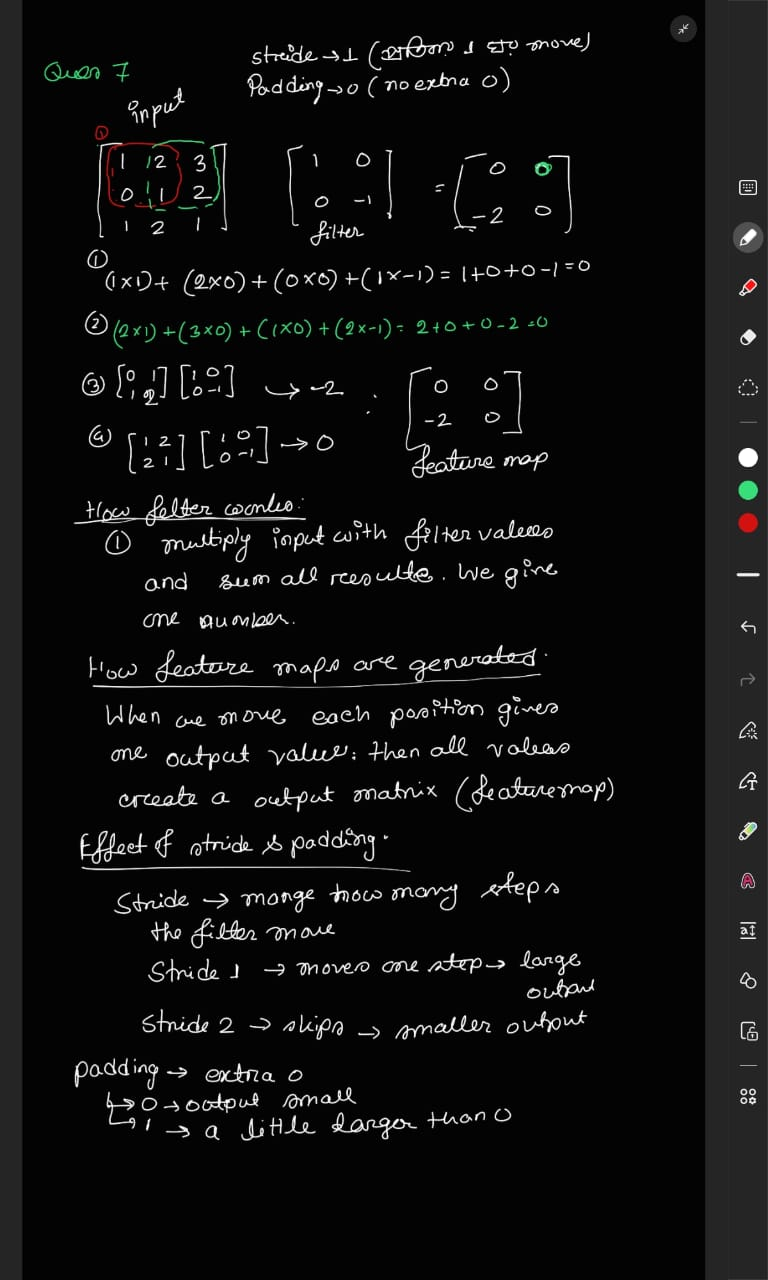


# Question 08: [ Marks 10 ]

## Explain the concept of pooling in CNNs. Compare MaxPooling and AveragePooling in terms of operation, advantages, and impact on feature extraction. Discuss how pooling helps in reducing overfitting and computational complexity.

Write Answer 08:

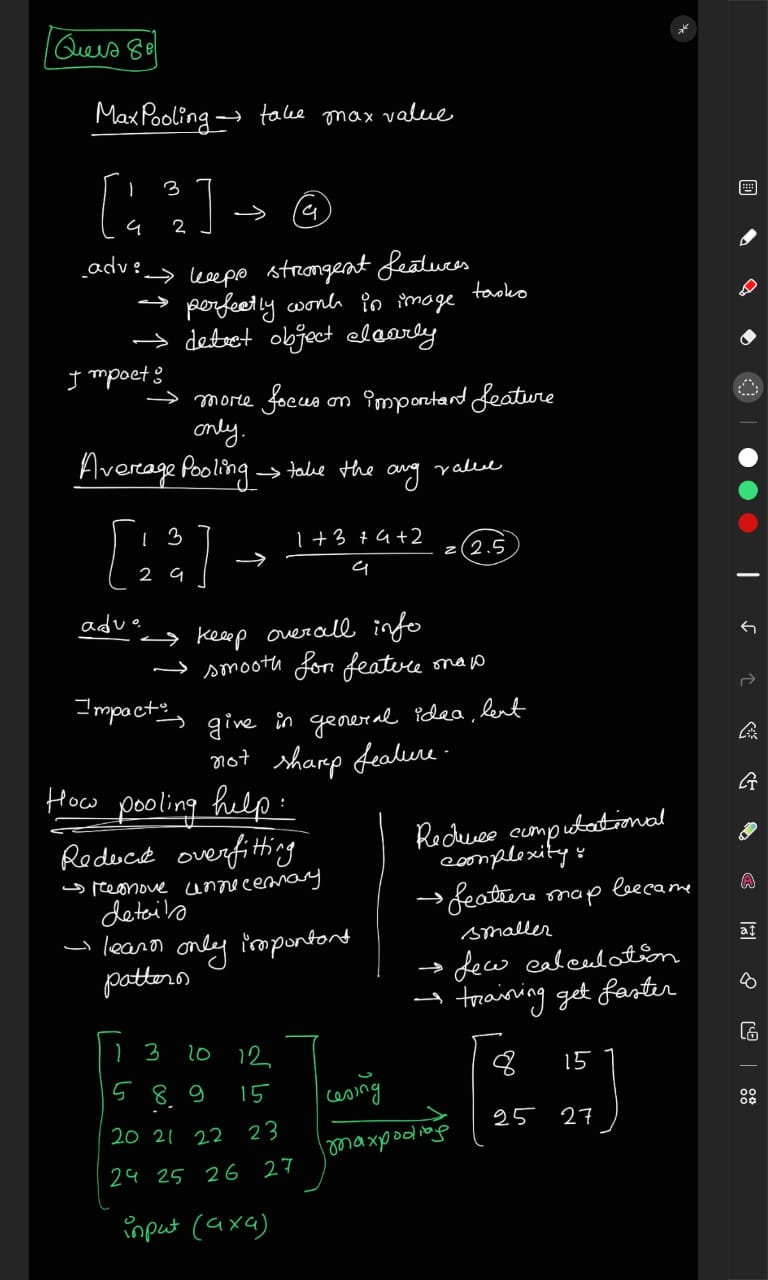

# Question 09: [ Marks 10 ]

## Given an input image of size 128×128×3, explain step-by-step how the dimensions change after multiple convolution and pooling layers. Clearly show calculations for output size after each layer using appropriate formulas.

# Write Answer 09

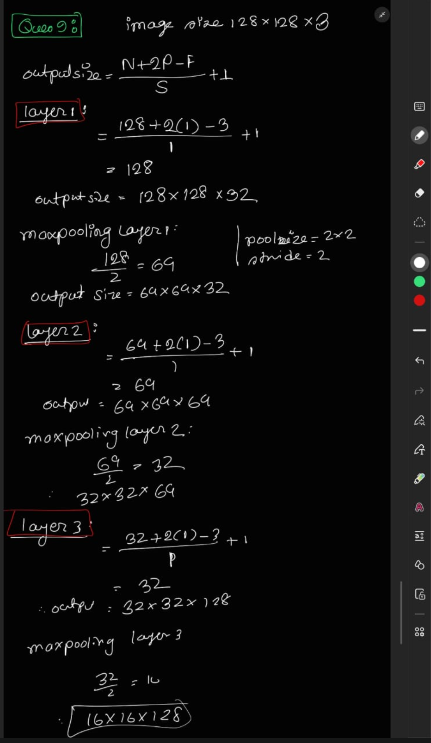

# Question 10: [ Marks 20 ]

## Design and implement a deep Convolutional Neural Network (CNN) for a multi-class image classification problem using PyTorch. The network should consist of four convolutional blocks, where each block includes two convolution layers followed by activation and normalization, and a pooling layer at the end. The number of filters should increase progressively across blocks. After the convolutional part, flatten the feature maps and connect them to fully connected layers with dropout for regularization, and produce final outputs corresponding to K classes. Also explain the role of each part of the network in detail.

# Write Answer 10:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import torch
print(torch.cuda.is_available())

True


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
#load dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.5MB/s]


In [5]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [6]:
# CNN model
class CNN4Block(nn.Module):
    def __init__(self):
        super(CNN4Block, self).__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )

        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 1 * 1, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.fc(x)
        return x

In [7]:
model = CNN4Block().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
#Training loop
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 142.16
Epoch 2, Loss: 124.82
Epoch 3, Loss: 110.84
Epoch 4, Loss: 94.47
Epoch 5, Loss: 80.39


In [10]:
#test accuracy
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total, "%")

Test Accuracy: 92.88 %


Convolution blocks: each block has 2 layers.

It learns features step by step:

Block 1 -> edges

Block 2 -> shapes

Block 3 -> parts

Block 4 -> full object

------

ReLU: helps model learn complex patterns

----

BatchNorm: helps model learn faster

------

MaxPooling: Keeps important information

--------

Increasing filters
32 -> 64 -> 128 -> 256
deeper layers learn more complex features

--------

